# 🧠 Neural Network Benchmark: ROCm vs CPU

This notebook benchmarks full neural network **inference** and **training** on ROCm (Radeon 890M) vs CPU.
Many ops queued into a single HIP kernel dispatch amortize dispatch overhead,
making this a more realistic test of MPS performance than standalone matmul.

In [1]:
import torch
import torchvision.models as models
from metalcheck import device_info, is_rocm_available
from metalcheck.utils import benchmark_model_inference, benchmark_model_training

## 1. Device & System Information

In [2]:
info = device_info()
for k, v in info.items():
    label = k.replace("_", " ").title()
    print(f"{label:<20s}: {v}")

Pytorch Version     : 2.8.0+rocm7.1.0.git7a520360
Python Version      : 3.12.3
Platform            : Linux-6.19.8-arch1-1-x86_64-with-glibc2.39
Architecture        : x86_64
Mps Built           : False
Mps Available       : False
Cuda Available      : True
Rocm Available      : True
Device              : cuda
Hip Version         : 7.1.25424-4179531dcd
Cuda Device Name    : AMD Radeon Graphics


## 2. Inference Benchmark

Time the forward pass of **ResNet-18** and **MobileNet V2** at various batch sizes.

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_theme(style="whitegrid")

model_configs = {
    "ResNet-18": models.resnet18,
    "MobileNet V2": models.mobilenet_v2,
}
batch_sizes = [1, 8, 32, 64]
inference_results = []

for model_name, factory in model_configs.items():
    for bs in batch_sizes:
        input_shape = (bs, 3, 224, 224)
        for dev_name, dev in [("ROCm", torch.device("cuda")), ("CPU", torch.device("cpu"))]:
            if dev_name == "ROCm" and not is_rocm_available():
                continue
            print(f"  {model_name} | batch={bs} | {dev_name} ...", end=" ", flush=True)
            r = benchmark_model_inference(factory, input_shape, device=dev, iterations=10)
            inference_results.append({
                "Model": model_name,
                "Batch": bs,
                "Device": dev_name,
                "Time (ms)": r["mean_time_s"] * 1000,
            })
            print(f"{r['mean_time_s']*1000:.2f} ms")

df_infer = pd.DataFrame(inference_results)
print("\nInference benchmark complete!")

  ResNet-18 | batch=1 | ROCm ... 5.46 ms
  ResNet-18 | batch=1 | CPU ... 21.16 ms
  ResNet-18 | batch=8 | ROCm ... 23.89 ms
  ResNet-18 | batch=8 | CPU ... 99.53 ms
  ResNet-18 | batch=32 | ROCm ... 73.94 ms
  ResNet-18 | batch=32 | CPU ... 355.45 ms
  ResNet-18 | batch=64 | ROCm ... 180.18 ms
  ResNet-18 | batch=64 | CPU ... 717.57 ms
  MobileNet V2 | batch=1 | ROCm ... 6.27 ms
  MobileNet V2 | batch=1 | CPU ... 10.26 ms
  MobileNet V2 | batch=8 | ROCm ... 44.12 ms
  MobileNet V2 | batch=8 | CPU ... 68.17 ms
  MobileNet V2 | batch=32 | ROCm ... 166.04 ms
  MobileNet V2 | batch=32 | CPU ... 317.95 ms
  MobileNet V2 | batch=64 | ROCm ... 325.27 ms
  MobileNet V2 | batch=64 | CPU ... 698.88 ms

Inference benchmark complete!


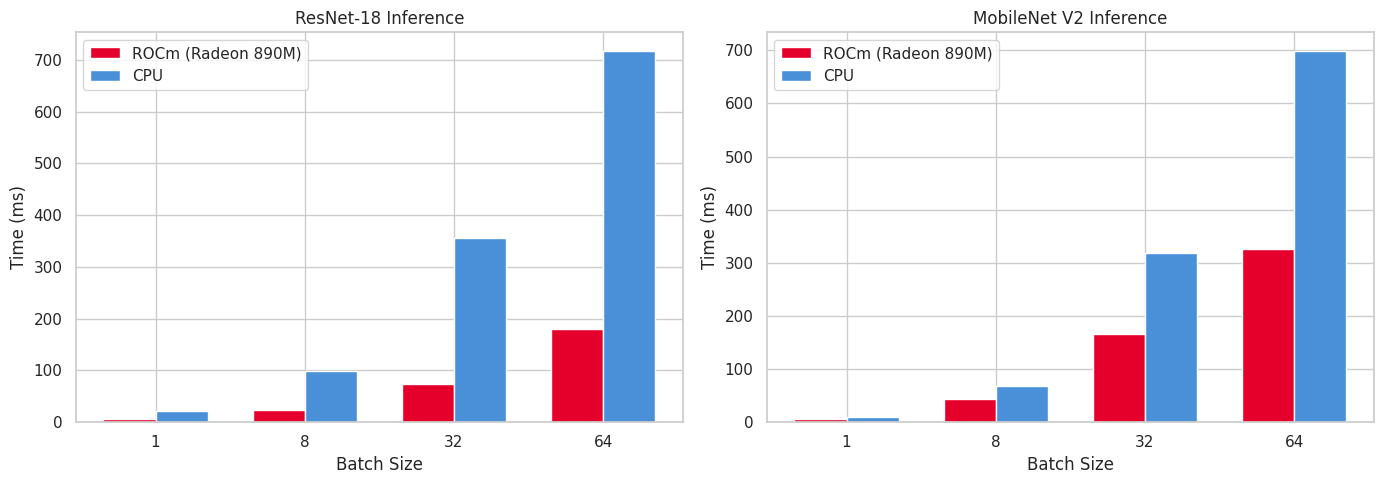

In [4]:
fig, axes = plt.subplots(1, len(model_configs), figsize=(14, 5), sharey=False)

for ax, model_name in zip(axes, model_configs):
    df_model = df_infer[df_infer["Model"] == model_name]
    x = range(len(batch_sizes))
    width = 0.35

    rocm_vals = df_model[df_model["Device"] == "ROCm"]["Time (ms)"].tolist()
    cpu_vals = df_model[df_model["Device"] == "CPU"]["Time (ms)"].tolist()

    if rocm_vals:
        ax.bar([i - width / 2 for i in x], rocm_vals, width, label="ROCm (Radeon 890M)", color="#E4002B")
    ax.bar([i + width / 2 for i in x], cpu_vals, width, label="CPU", color="#4A90D9")

    ax.set_xlabel("Batch Size")
    ax.set_ylabel("Time (ms)")
    ax.set_title(f"{model_name} Inference")
    ax.set_xticks(list(x))
    ax.set_xticklabels([str(bs) for bs in batch_sizes])
    ax.legend()

plt.tight_layout()
plt.show()

### Inference Speedup Summary

In [5]:
if is_rocm_available():
    rows = []
    for model_name in model_configs:
        for bs in batch_sizes:
            rocm_t = df_infer[(df_infer["Model"] == model_name) & (df_infer["Batch"] == bs) & (df_infer["Device"] == "ROCm")]["Time (ms)"].values[0]
            cpu_t = df_infer[(df_infer["Model"] == model_name) & (df_infer["Batch"] == bs) & (df_infer["Device"] == "CPU")]["Time (ms)"].values[0]
            rows.append({"Model": model_name, "Batch": bs, "ROCm (ms)": f"{rocm_t:.2f}", "CPU (ms)": f"{cpu_t:.2f}", "Speedup": f"{cpu_t / rocm_t:.1f}x"})
    display(pd.DataFrame(rows))
else:
    print("ROCm not available — ran CPU only.")

,Model,Batch,ROCm (ms),CPU (ms),Speedup
0,ResNet-18,1,5.46,21.16,3.9x
1,ResNet-18,8,23.89,99.53,4.2x
2,ResNet-18,32,73.94,355.45,4.8x
3,ResNet-18,64,180.18,717.57,4.0x
4,MobileNet V2,1,6.27,10.26,1.6x
5,MobileNet V2,8,44.12,68.17,1.5x
6,MobileNet V2,32,166.04,317.95,1.9x
7,MobileNet V2,64,325.27,698.88,2.1x


## 3. Training Benchmark

Time a full training step (forward + cross-entropy loss + backward + SGD optimizer step)
for **ResNet-18** with synthetic data.

In [6]:
train_batch_sizes = [1, 8, 32]
training_results = []

for bs in train_batch_sizes:
    input_shape = (bs, 3, 224, 224)
    for dev_name, dev in [("ROCm", torch.device("cuda")), ("CPU", torch.device("cpu"))]:
        if dev_name == "ROCm" and not is_rocm_available():
            continue
        print(f"  ResNet-18 training | batch={bs} | {dev_name} ...", end=" ", flush=True)
        r = benchmark_model_training(models.resnet18, input_shape, num_classes=1000, device=dev, steps=20)
        training_results.append({
            "Batch": bs,
            "Device": dev_name,
            "Time (ms)": r["mean_time_s"] * 1000,
        })
        print(f"{r['mean_time_s']*1000:.2f} ms/step")

df_train = pd.DataFrame(training_results)
print("\nTraining benchmark complete!")

  ResNet-18 training | batch=1 | ROCm ... 17.29 ms/step
  ResNet-18 training | batch=1 | CPU ... 49.97 ms/step
  ResNet-18 training | batch=8 | ROCm ... 82.60 ms/step
  ResNet-18 training | batch=8 | CPU ... 223.79 ms/step
  ResNet-18 training | batch=32 | ROCm ... 363.00 ms/step
  ResNet-18 training | batch=32 | CPU ... 900.99 ms/step

Training benchmark complete!


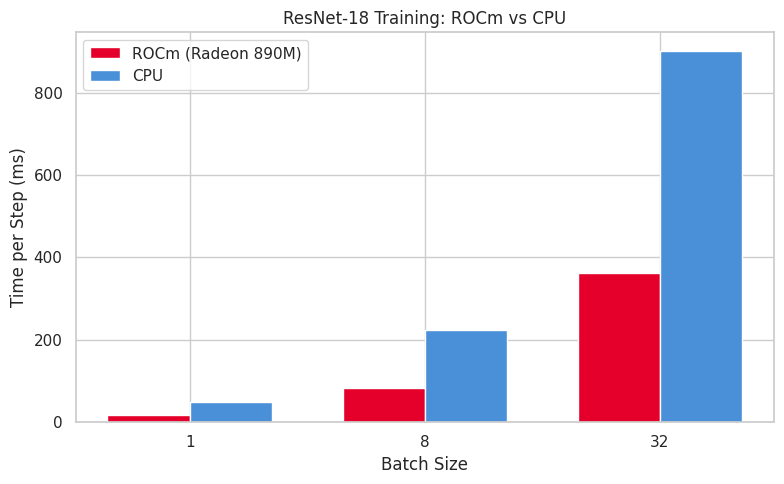

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))

x = range(len(train_batch_sizes))
width = 0.35

rocm_vals = df_train[df_train["Device"] == "ROCm"]["Time (ms)"].tolist()
cpu_vals = df_train[df_train["Device"] == "CPU"]["Time (ms)"].tolist()

if rocm_vals:
    ax.bar([i - width / 2 for i in x], rocm_vals, width, label="ROCm (Radeon 890M)", color="#E4002B")
ax.bar([i + width / 2 for i in x], cpu_vals, width, label="CPU", color="#4A90D9")

ax.set_xlabel("Batch Size")
ax.set_ylabel("Time per Step (ms)")
ax.set_title("ResNet-18 Training: ROCm vs CPU")
ax.set_xticks(list(x))
ax.set_xticklabels([str(bs) for bs in train_batch_sizes])
ax.legend()

plt.tight_layout()
plt.show()

### Training Speedup Summary

In [8]:
if is_rocm_available():
    rows = []
    for bs in train_batch_sizes:
        rocm_t = df_train[(df_train["Batch"] == bs) & (df_train["Device"] == "ROCm")]["Time (ms)"].values[0]
        cpu_t = df_train[(df_train["Batch"] == bs) & (df_train["Device"] == "CPU")]["Time (ms)"].values[0]
        rows.append({"Batch": bs, "ROCm (ms)": f"{rocm_t:.2f}", "CPU (ms)": f"{cpu_t:.2f}", "Speedup": f"{cpu_t / rocm_t:.1f}x"})
    display(pd.DataFrame(rows))
else:
    print("ROCm not available — ran CPU only.")

,Batch,ROCm (ms),CPU (ms),Speedup
0,1,17.29,49.97,2.9x
1,8,82.60,223.79,2.7x
2,32,363.00,900.99,2.5x
